In [10]:
import pandas as pd

df = pd.read_csv('../datasets/electricity_consumption_and_production.csv')

print("All colums:", df.columns.tolist())

print(df.head())

All colums: ['DateTime', 'Consumption', 'Production', 'Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass']
              DateTime  Consumption  Production  Nuclear  Wind  Hydroelectric  \
0  2019-01-01 00:00:00         6352        6527     1395    79           1383   
1  2019-01-01 01:00:00         6116        5701     1393    96           1112   
2  2019-01-01 02:00:00         5873        5676     1393   142           1030   
3  2019-01-01 03:00:00         5682        5603     1397   191            972   
4  2019-01-01 04:00:00         5557        5454     1393   159            960   

   Oil and Gas  Coal  Solar  Biomass  
0         1896  1744      0       30  
1         1429  1641      0       30  
2         1465  1616      0       30  
3         1455  1558      0       30  
4         1454  1458      0       30  


In [11]:
df['DateTime'] = pd.to_datetime(df['DateTime'])
df.set_index('DateTime', inplace=True)

daily_df = df['Consumption'].resample('D').sum()

print(daily_df.head())

DateTime
2019-01-01    136263
2019-01-02    151729
2019-01-03    174098
2019-01-04    183242
2019-01-05    170741
Freq: D, Name: Consumption, dtype: int64


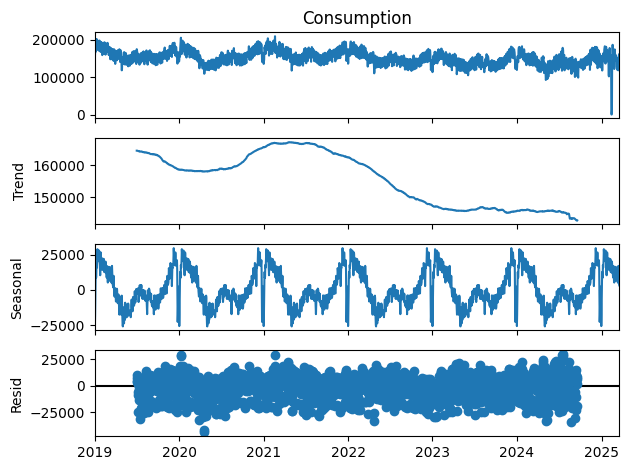

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

result = seasonal_decompose(daily_df, model='additive', period=365)

result.plot()
plt.show()

ADF Statistic: -3.2628499042915986
p-value: 0.016622983293717395


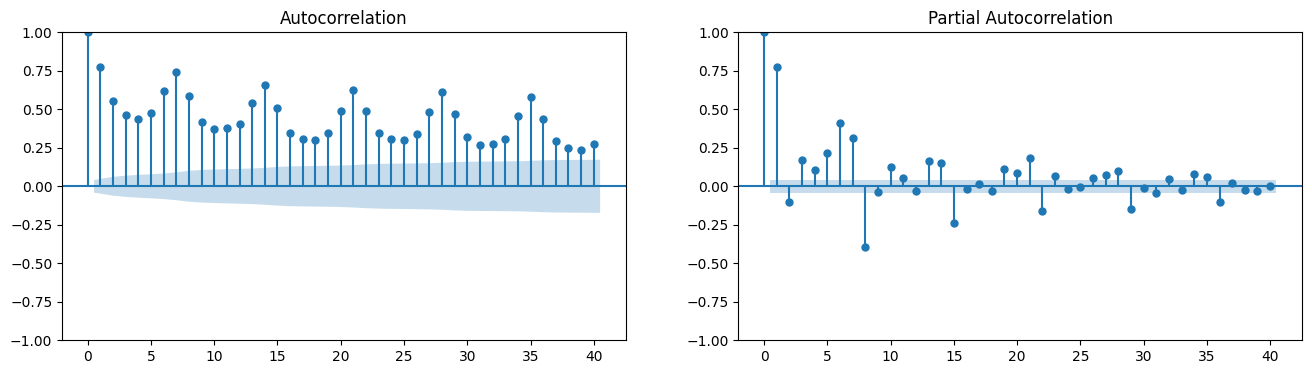

In [13]:
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

result = adfuller(daily_df)
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(daily_df, ax=ax1, lags=40)
plot_pacf(daily_df, ax=ax2, lags=40)
plt.show()

In [14]:
missing_values = daily_df.isnull().sum()
print(f"Amount of missed values: {missing_values}")

if missing_values > 0:
    daily_df = daily_df.fillna(method='ffill')
    print("Spaces filled.")

Amount of missed values: 0


In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train = daily_df[:-45]
test = daily_df[-45:]

model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0), enforce_stationarity=False)
model_fit = model.fit(disp=False)
forecast = model_fit.forecast(steps=45)

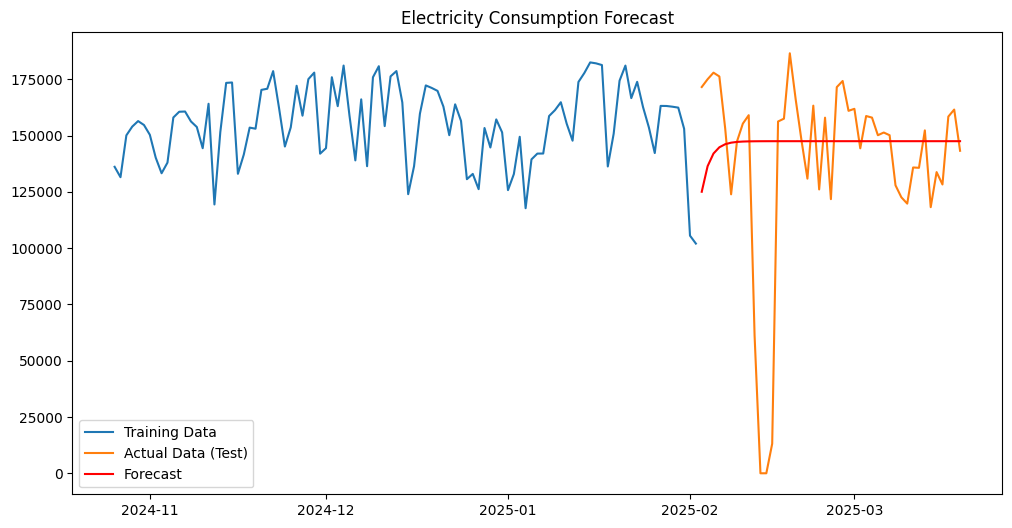

MAE: 26428.280404999285
RMSE: 43550.08589755218


In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

plt.figure(figsize=(12, 6))
plt.plot(train.index[-100:], train[-100:], label='Training Data')
plt.plot(test.index, test, label='Actual Data (Test)')
plt.plot(test.index, forecast, label='Forecast', color='red')
plt.legend()
plt.title('Electricity Consumption Forecast')
plt.show()

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print(f'MAE: {mae}')
print(f'RMSE: {rmse}')